# ViT 기반 Semantic Segmentation 실습 — Google Colab

이 Notebook은 **ViT → Patch Token → 2D Feature Map → Segmentation Decoder → Pixel-wise Prediction**의 전체 흐름을 직접 구현합니다.

### 학습 목표
- ViT의 classification 출력과 segmentation용 spatial token의 차이 이해
- `[B, N, D] → [B, D, H', W']` 변환 이해
- 간단한 segmentation decoder 구현
- CE + Dice Loss 학습
- IoU / Dice / F1 / Pixel Accuracy 계산
- Original / Ground Truth / Prediction / Overlay 시각화
- 기존 Notebook의 `classification logits를 14×14로 복제`하는 방식이 왜 올바른 segmentation이 아닌지 확인
- 마지막에 Cityscapes / SegFormer로 확장할 수 있는 구조 이해

> **주의:** 교육용으로 Colab GPU에서 빠르게 실행할 수 있도록 Oxford-IIIT Pet의 binary foreground segmentation을 사용합니다. 이후 Cityscapes로 확장하는 방법도 마지막에 설명합니다.


In [1]:
# ============================================================
# 1. Colab 환경 확인 및 라이브러리 설치
# ============================================================
!nvidia-smi

!pip -q install timm==1.0.19


Wed Oct  7 05:24:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

import timm

print("PyTorch :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA available :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


PyTorch : 2.11.0+cu130
Torchvision : 0.26.0+cu130
CUDA available : True
Device : cuda


## 2. Dataset

Oxford-IIIT Pet의 segmentation mask를 사용합니다.

여기서는 문제를 단순화하여:

- `0` = background
- `1` = pet foreground

의 **binary semantic segmentation**으로 처리합니다.

이미지는 ViT-B/16에 맞춰 `224×224`로 resize합니다.


In [3]:
# ============================================================
# 2. Oxford-IIIT Pet Dataset
# ============================================================

IMG_SIZE = 224

base = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True
)

print("Dataset size:", len(base))
print("Example image size:", base[0][0].size)
print("Example mask size :", base[0][1].size)


100%|██████████| 792M/792M [00:30<00:00, 25.8MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.39MB/s]


Dataset size: 3680
Example image size: (394, 500)
Example mask size : (394, 500)


In [4]:
# ============================================================
# 3. Segmentation Dataset Wrapper
#
# torchvision dataset의 segmentation mask를
# binary mask(0=background, 1=pet)로 변환합니다.
# ============================================================

class PetSegmentationDataset(Dataset):
    def __init__(self, root="./data", split="trainval", image_size=224):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )
        self.image_size = image_size

        self.image_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        # Image
        image = self.image_transform(image)

        # Mask는 nearest interpolation을 사용해야 합니다.
        # bilinear를 사용하면 class ID가 섞인 실수값이 만들어질 수 있습니다.
        mask = mask.resize(
            (self.image_size, self.image_size),
            Image.Resampling.NEAREST
        )

        mask = np.array(mask)

        # Oxford-IIIT Pet trimap:
        # 1 = foreground
        # 2 = background
        # 3 = boundary
        #
        # 교육 목적상 foreground를 1,
        # 나머지를 0으로 변환합니다.
        mask = (mask == 1).astype(np.int64)

        mask = torch.from_numpy(mask)

        return image, mask


dataset = PetSegmentationDataset(image_size=IMG_SIZE)

train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))


Train: 2944
Validation: 736


In [5]:
# ============================================================
# 4. DataLoader
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, masks = next(iter(train_loader))

print("Image batch:", images.shape)
print("Mask batch :", masks.shape)
print("Mask values:", torch.unique(masks))


Image batch: torch.Size([8, 3, 224, 224])
Mask batch : torch.Size([8, 224, 224])
Mask values: tensor([0, 1])


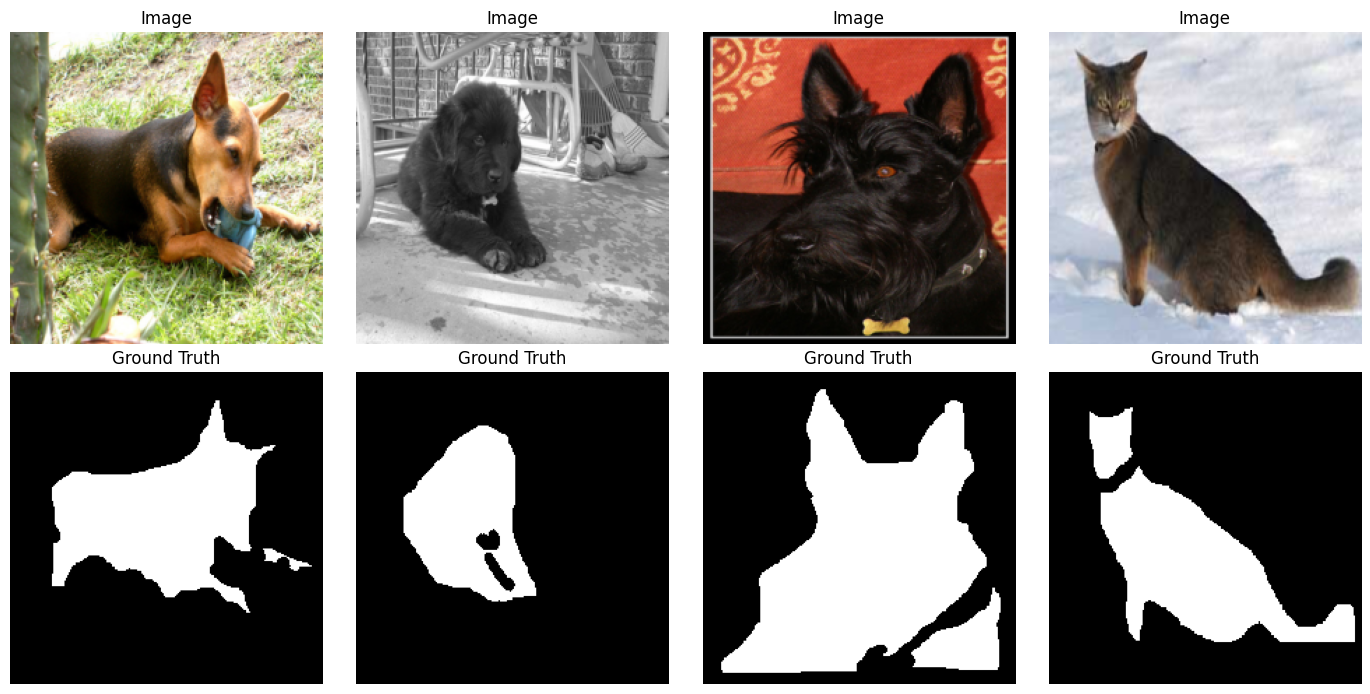

In [6]:
# ============================================================
# 5. Dataset 시각화
# ============================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img.cpu() * std + mean
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    axes[0, i].imshow(denormalize(images[i]).permute(1,2,0))
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")

    axes[1, i].imshow(masks[i], cmap="gray")
    axes[1, i].set_title("Ground Truth")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


# 6. 핵심: ViT에서 Patch Token 가져오기

일반적인 ViT classification은 최종적으로:

```text
Image
 ↓
Patch Embedding
 ↓
Transformer
 ↓
CLS Token
 ↓
Linear Classifier
 ↓
[B, 1000]
```

를 만듭니다.

Semantic segmentation에서는 최종 classification 결과 `[B,1000]`을 사용하는 것이 아니라 **각 이미지 patch에 해당하는 token**을 사용해야 합니다.

예를 들어 `224×224`, patch size `16`이면:

```text
224 / 16 = 14

14 × 14 = 196 patches
```

따라서 patch token은 대략:

```text
[B, 196, D]
```

형태가 됩니다.

이를:

```text
[B, 196, D]
      ↓
[B, 14, 14, D]
      ↓
[B, D, 14, 14]
```

로 변환하면 spatial feature map으로 사용할 수 있습니다.


In [7]:
# ============================================================
# 6. ViT Backbone
#
# timm의 ViT를 사용합니다.
# num_classes=0으로 설정하여 classification head를 제거합니다.
# ============================================================

vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=0
)

vit = vit.to(device)
vit.eval()

print(vit)


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [8]:
# ============================================================
# 7. ViT Feature Shape 확인
# ============================================================

x = images[:2].to(device)

with torch.no_grad():
    features = vit.forward_features(x)

print("Input :", x.shape)
print("ViT output :", features.shape)

# 일반적인 timm ViT-B/16:
# [B, 197, 768]
#
# 197 = CLS token 1개 + patch token 196개
#
# segmentation에서는 CLS token을 제거합니다.

patch_tokens = features[:, 1:, :]

print("Patch tokens:", patch_tokens.shape)

B, N, D = patch_tokens.shape
H = W = int(N ** 0.5)

print("Number of patches:", N)
print("Grid:", H, "x", W)
print("Embedding dimension:", D)


Input : torch.Size([2, 3, 224, 224])
ViT output : torch.Size([2, 197, 768])
Patch tokens: torch.Size([2, 196, 768])
Number of patches: 196
Grid: 14 x 14
Embedding dimension: 768


In [9]:
# ============================================================
# 8. [B,N,D] -> [B,D,H,W]
# ============================================================

feature_map = patch_tokens.reshape(B, H, W, D)
feature_map = feature_map.permute(0, 3, 1, 2)

print("Before:", patch_tokens.shape)
print("After :", feature_map.shape)

# 예상:
# [2, 196, 768]
#      ↓
# [2, 768, 14, 14]


Before: torch.Size([2, 196, 768])
After : torch.Size([2, 768, 14, 14])


## 9. ViT segmentation은:

```text
[B,196,768]
```

처럼 **196개(= 14*14개) patch 각각의 feature**를 사용합니다.

즉 위치 정보가:

```text
patch 1
patch 2
patch 3
...
patch 196
```

으로 유지됩니다.


In [10]:
# ============================================================
# 10. 실제 patch token은 위치마다 서로 다릅니다.
# ============================================================

a = patch_tokens[0, 0]
b = patch_tokens[0, 1]

print("Patch 0 feature mean:", a.mean().item())
print("Patch 1 feature mean:", b.mean().item())
print("두 patch feature가 동일한가?", torch.allclose(a, b))


Patch 0 feature mean: -0.03386929631233215
Patch 1 feature mean: -0.04975520819425583
두 patch feature가 동일한가? False


# 11. Segmentation Model

이제 ViT feature를 segmentation decoder에 연결합니다.

구조:

```text
Input
  ↓
ViT-B/16
  ↓
Patch Tokens [B,196,768]
  ↓
Reshape
  ↓
[B,768,14,14]
  ↓
Conv + Upsampling
  ↓
[B,2,224,224]
```

2개 class:

- 0 = background
- 1 = pet


In [11]:
# ============================================================
# 11. Simple ViT Segmentation Model
# ============================================================

class ViTSegmentation(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Pretrained ViT
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        embed_dim = self.backbone.num_features

        # 간단한 segmentation decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            nn.Conv2d(64, num_classes, 1)
        )

    def forward(self, x):

        # ViT:
        # [B,3,224,224]
        #       ↓
        # [B,197,768]
        features = self.backbone.forward_features(x)

        # CLS token 제거
        patch_tokens = features[:, 1:, :]

        B, N, D = patch_tokens.shape

        # 196 = 14 × 14
        H = W = int(N ** 0.5)

        # [B,196,768]
        #       ↓
        # [B,14,14,768]
        feature_map = patch_tokens.reshape(B, H, W, D)

        # [B,14,14,768]
        #       ↓
        # [B,768,14,14]
        feature_map = feature_map.permute(0, 3, 1, 2)

        # Decoder
        logits = self.decoder(feature_map)

        return logits


model = ViTSegmentation(num_classes=2).to(device)

with torch.no_grad():
    test_out = model(x)

print("Input :", x.shape)
print("Output:", test_out.shape)


Input : torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 2, 224, 224])


## 12. Decoder에서 해상도가 어떻게 증가하는가?

ViT patch feature는:

```text
14 × 14
```

입니다.

Decoder에서 2배씩 확대합니다.

```text
14 × 14
 ↓ ×2
28 × 28
 ↓ ×2
56 × 56
 ↓ ×2
112 × 112
 ↓ ×2
224 × 224
```

따라서 최종 출력:

```text
[B, 2, 224, 224]
```

가 됩니다.

여기서 `2`는 background / pet 두 class의 logit입니다.


# 13. Dice Loss

Binary segmentation에서 Dice는 다음과 같습니다.

$$
Dice = \frac{2|P \cap G|}{|P|+|G|}
$$

Loss는:

$$
DiceLoss = 1-Dice
$$

CE와 Dice를 같이 사용합니다.

$$
Loss = CE + \lambda DiceLoss
$$

여기서 λ는 두 loss의 상대적인 중요도를 조절하는 **가중치**입니다.


In [12]:
# ============================================================
# 13. Dice Loss + CE Loss
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        # Binary foreground probability
        probs = torch.softmax(logits, dim=1)[:, 1]

        targets = targets.float()

        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum(dim=1) +
            targets.sum(dim=1) +
            self.smooth
        )

        return 1 - dice.mean()


ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

LAMBDA_DICE = 1.0

def segmentation_loss(logits, targets):
    ce = ce_loss(logits, targets)
    dice = dice_loss(logits, targets)

    total = ce + LAMBDA_DICE * dice

    return total, ce.detach(), dice.detach()


In [13]:
# ============================================================
# 14. Metrics
# ============================================================

def calculate_metrics(logits, targets, eps=1e-7):

    preds = torch.argmax(logits, dim=1)

    pred = preds == 1
    target = targets == 1

    tp = (pred & target).sum().float()
    fp = (pred & ~target).sum().float()
    fn = (~pred & target).sum().float()
    tn = (~pred & ~target).sum().float()

    iou = tp / (tp + fp + fn + eps)

    dice = (2 * tp) / (2 * tp + fp + fn + eps)

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    f1 = 2 * precision * recall / (
        precision + recall + eps
    )

    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "IoU": iou.item(),
        "Dice": dice.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
        "F1": f1.item(),
        "Pixel Accuracy": accuracy.item()
    }


# 15. Training

Colab GPU에서 실행 시간을 줄이기 위해 우선 backbone을 freeze하고 decoder를 학습합니다.

이 방식은 **ViT segmentation 구조를 이해하기 위한 교육용 설정**입니다.

이후 전체 ViT를 fine-tuning하면:

```text
Decoder만 학습
        ↓
ViT + Decoder 전체 Fine-tuning
```

으로 확장할 수 있습니다.


In [14]:
# ============================================================
# 15. Backbone Freeze
# ============================================================

for param in model.backbone.parameters():
    param.requires_grad = False

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters    : {total_params:,}")


Trainable parameters: 5,090,242
Total parameters    : 90,888,898


In [15]:
# ============================================================
# 16. Optimizer / AMP
# ============================================================

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

EPOCHS = 3


In [16]:
# ============================================================
# 17. Training Loop
# ============================================================

def train_one_epoch(model, loader):

    model.train()

    # backbone은 freeze되어 있지만
    # BatchNorm 등의 decoder layer는 train mode가 필요합니다.
    total_loss = 0

    for images, masks in loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)

            loss, ce, dice = segmentation_loss(
                logits,
                masks
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader):

    model.eval()

    total_loss = 0
    metric_sum = {
        "IoU": 0,
        "Dice": 0,
        "Precision": 0,
        "Recall": 0,
        "F1": 0,
        "Pixel Accuracy": 0
    }

    for images, masks in loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)

        loss, _, _ = segmentation_loss(
            logits,
            masks
        )

        total_loss += loss.item()

        metrics = calculate_metrics(
            logits,
            masks
        )

        for key in metric_sum:
            metric_sum[key] += metrics[key]

    n = len(loader)

    return (
        total_loss / n,
        {key: value / n for key, value in metric_sum.items()}
    )


for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    val_loss, metrics = validate(
        model,
        val_loader
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"IoU: {metrics['IoU']:.4f} "
        f"Dice: {metrics['Dice']:.4f} "
        f"F1: {metrics['F1']:.4f}"
    )


Epoch [1/3] Train Loss: 0.4344 Val Loss: 0.3096 IoU: 0.8355 Dice: 0.9101 F1: 0.9101
Epoch [2/3] Train Loss: 0.2860 Val Loss: 0.2669 IoU: 0.8422 Dice: 0.9141 F1: 0.9141
Epoch [3/3] Train Loss: 0.2391 Val Loss: 0.2428 IoU: 0.8518 Dice: 0.9197 F1: 0.9197


# 18. Prediction 시각화

Segmentation에서 중요한 부분입니다.

단순히:

```python
prediction = argmax(logits, dim=1)
```

만 해서 grayscale PNG로 저장하는 것보다,

1. Original
2. Ground Truth
3. Prediction
4. Overlay

를 함께 보는 것이 좋습니다.


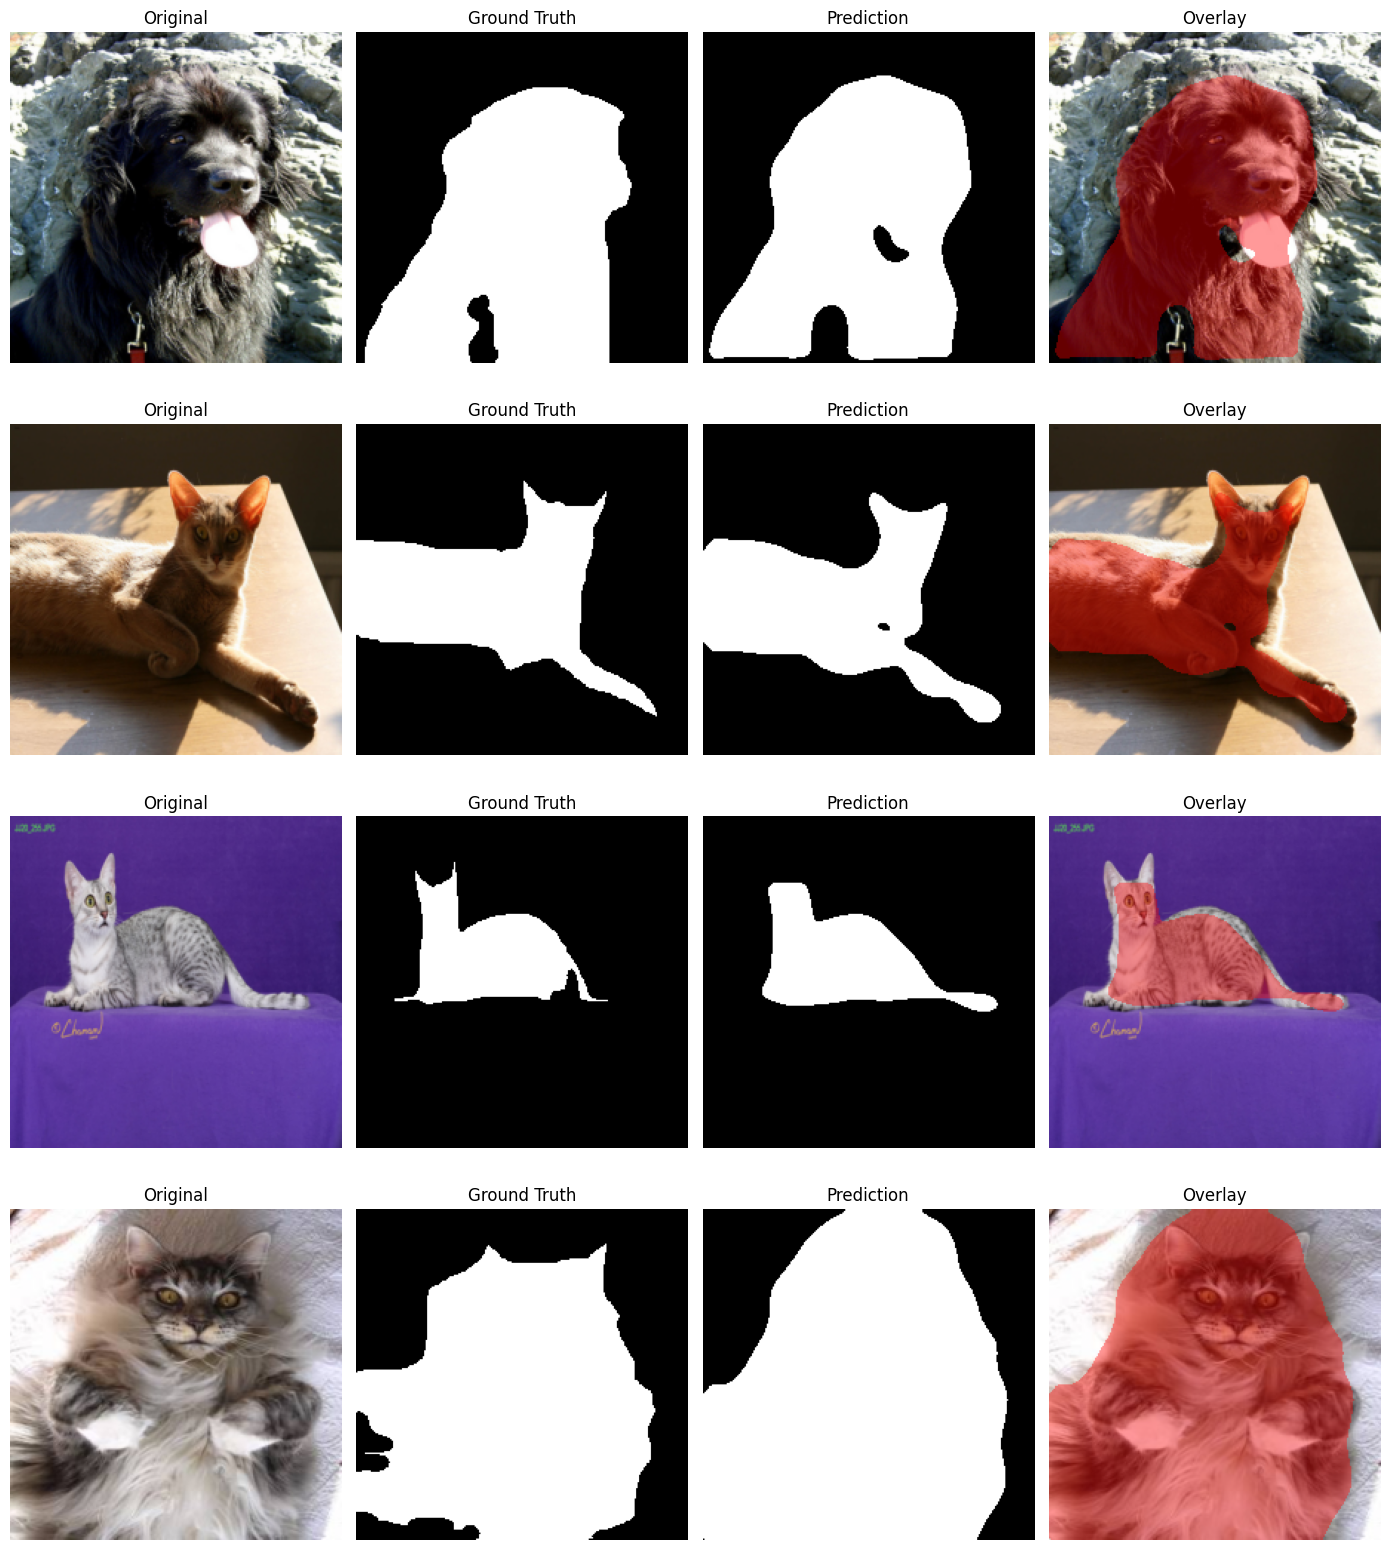

In [17]:
# ============================================================
# 18. Segmentation Visualization
# ============================================================

def visualize_predictions(model, loader, num_images=4):

    model.eval()

    images, masks = next(iter(loader))

    images_device = images.to(device)

    with torch.no_grad():
        logits = model(images_device)
        preds = torch.argmax(logits, dim=1).cpu()

    num_images = min(num_images, len(images))

    fig, axes = plt.subplots(
        num_images,
        4,
        figsize=(14, 4 * num_images)
    )

    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_images):

        img = denormalize(images[i]).permute(1,2,0).numpy()
        gt = masks[i].numpy()
        pred = preds[i].numpy()

        # Overlay
        overlay = img.copy()

        # foreground prediction을 반투명하게 표시
        overlay[pred == 1] = (
            0.6 * overlay[pred == 1] +
            0.4 * np.array([1.0, 0.0, 0.0])
        )

        axes[i,0].imshow(img)
        axes[i,0].set_title("Original")

        axes[i,1].imshow(gt, cmap="gray")
        axes[i,1].set_title("Ground Truth")

        axes[i,2].imshow(pred, cmap="gray")
        axes[i,2].set_title("Prediction")

        axes[i,3].imshow(overlay)
        axes[i,3].set_title("Overlay")

        for j in range(4):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(
    model,
    val_loader,
    num_images=4
)


# 19. Pixel별 segmentation이 실제로 무엇을 의미하는가?

최종 출력은:

```text
[B, 2, 224, 224]
```

입니다.

예를 들어 한 pixel `(100,150)`에 대해:

```text
background logit = 0.3
pet logit        = 2.1
```

이면:

```python
argmax(...)
```

결과는:

```text
pet = 1
```

입니다.

즉 segmentation은 **이미지 전체에 하나의 class를 부여하는 것이 아니라 모든 pixel에 class를 부여합니다.**

Classification:

```text
Image → Cat
```

Segmentation:

```text
Pixel(0,0)     → background
Pixel(0,1)     → background
Pixel(0,2)     → pet
...
Pixel(223,223) → background
```


# 20. ViT Segmentation 핵심 정리

## Classification ViT

```text
Image
 ↓
Patch Embedding
 ↓
Transformer
 ↓
CLS Token
 ↓
Linear
 ↓
[B, NumClasses]
```

## Segmentation ViT

```text
Image
 ↓
Patch Embedding
 ↓
Transformer
 ↓
Patch Tokens
 ↓
[B,N,D]
 ↓
[B,D,H',W']
 ↓
Segmentation Decoder
 ↓
[B,C,H,W]
```

### 가장 중요한 차이

**Classification은 CLS token을 중심으로 전체 이미지를 분류합니다.**

**Segmentation은 각 patch의 spatial token을 유지하여 위치별 prediction을 만듭니다.**


# 21. Cityscapes로 확장하기

현재 Notebook:

```text
Oxford-IIIT Pet
↓
Binary Segmentation
↓
224×224
↓
2 classes
```

Cityscapes에서는:

```text
Cityscapes
↓
Semantic Segmentation
↓
19 evaluation classes
↓
고해상도 이미지
```

로 변경합니다.

특히 Cityscapes에서는 원본 label ID와 학습용 `trainId`를 매핑해야 하며 `255`는 일반적으로 ignore label로 처리합니다.

Loss:

```python
criterion = nn.CrossEntropyLoss(ignore_index=255)
```

형태로 사용할 수 있습니다.

또한 실제 Cityscapes에서는 단순한 14×14 decoder보다 **multi-scale feature decoder**가 성능상 유리합니다.

실무/연구에서는 다음 계열을 추천합니다.

- Segmenter: ViT segmentation 원리 학습
- SegFormer: 실무적인 Transformer segmentation
- SETR: Transformer 기반 segmentation 연구


# 22. 다음 단계: ViT → VLM 연결

이 Notebook에서 얻은 핵심은 VLM에도 그대로 연결됩니다.

ViT:

```text
Image
 ↓
Patch Tokens
[B,N,D]
```

VLM:

```text
Image
 ↓
ViT
 ↓
Patch Tokens
[B,N,D]
 ↓
Projection Layer
 ↓
LLM embedding dimension
 ↓
LLM
 ↓
Text
```

따라서 **VLM을 만들기 위해 반드시 ViT를 segmentation 구조로 만들 필요는 없습니다.**

다만 다음 목적이라면 segmentation/vision decoder가 필요합니다.

```text
Image → Text
```

는 VLM

```text
Image → Pixel Mask
```

는 Segmentation

```text
Image + Text → Pixel Mask
```

는 **Vision-Language Segmentation / Referring Segmentation**

입니다.

즉 사용자가 앞서 질문한:

> "ViT 뒤에 LLM을 붙여 VLM을 fine-tuning할 때 ViT를 segmentation 구조로 가져가야 하는가?"

에 대한 답은 **아니오**입니다.

VLM에서는 일반적으로 ViT의 **patch tokens를 LLM으로 전달**하면 됩니다.


# 23. 실습 과제

### 실습 1
다음 값을 출력해 보세요.

```python
print(features.shape)
print(patch_tokens.shape)
print(feature_map.shape)
```

### 실습 2
`LAMBDA_DICE`를:

```text
0
0.5
1
2
```

로 바꾸면서 segmentation 결과를 비교해 보세요.

### 실습 3
ViT backbone을 freeze하지 않고 전체 fine-tuning해 보세요.

```python
for param in model.backbone.parameters():
    param.requires_grad = True
```

### 실습 4
Decoder의 `Upsample` 구조를 `ConvTranspose2d` 구조로 변경해 보세요.

### 실습 5
Binary segmentation을 multi-class segmentation으로 변경해 보세요.

### 실습 6
마지막으로 Cityscapes의 19-class segmentation으로 확장해 보세요.
